### 1. Project Overview
This project builds an AutoJudge system that predicts both the difficulty class (Easy / Medium / Hard) and difficulty score (0–10) of competitive programming problems purely from their textual statements.

Key ideas:

- Represent the merged problem text with TF–IDF n‑grams to capture lexical and phrase-level information.

- Add handcrafted numeric features (length, math symbols, algorithm keywords, constraints) to encode structural and algorithmic hints that are known to correlate with difficulty.

- Train two models on the same feature space:

  -> Classification: multinomial Logistic Regression

  
  ->Regression: Gradient Boosting Regressor

### 2. Imports and Dataset Loading
In this section:

- Import all necessary Python libraries for:

  - Data handling (pandas, numpy)

  - Text processing (re, scikit-learn’s TfidfVectorizer)

  - Modeling (LogisticRegression, GradientBoostingRegressor)

  - Evaluation (accuracy, confusion matrix, MAE, RMSE)

- Load the provided data.jsonl file, which contains one JSON object per line, each representing a problem.

- Inspect the basic structure to verify columns and check for missing values.

In [1]:
import numpy as np
import pandas as pd
import re
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# For nicer plots
sns.set(style="whitegrid")

# Path to dataset
DATA_PATH = "data.jsonl"  # adjust if needed

# Load JSONL dataset
df = pd.read_json(DATA_PATH, lines=True)

df.head()


,title,description,input_description,output_description,sample_io,problem_class,problem_score,url
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,"[{'input': '7 10', 'output': '1 2 2 3 1 3 3 4 ...",hard,9.7,https://open.kattis.com/problems/uuu
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,"[{'input': '0 2 3 2 50 60 50 30 50 40', 'outpu...",hard,9.7,https://open.kattis.com/problems/husbygge
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,"[{'input': '', 'output': ''}]",hard,9.6,https://open.kattis.com/problems/marioorluigi
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,"[{'input': '4 3 3 C 2 C 1 C', 'output': 'GHOST...",hard,9.6,https://open.kattis.com/problems/thewireghost
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,"[{'input': '2 0 10 0 10 10', 'output': '14.14'...",hard,9.6,https://open.kattis.com/problems/barktree


In [2]:
# Basic info and null check
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4112 entries, 0 to 4111
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               4112 non-null   object 
 1   description         4112 non-null   object 
 2   input_description   4112 non-null   object 
 3   output_description  4112 non-null   object 
 4   sample_io           4112 non-null   object 
 5   problem_class       4112 non-null   object 
 6   problem_score       4112 non-null   float64
 7   url                 4112 non-null   object 
dtypes: float64(1), object(7)
memory usage: 257.1+ KB
None

Missing values per column:
 title                 0
description           0
input_description     0
output_description    0
sample_io             0
problem_class         0
problem_score         0
url                   0
dtype: int64


### 3. Data Understanding and Basic Cleaning
The raw dataset has the following core columns:

- title

- description

- input_description

- output_description

- sample_io

- problem_class (Easy / Medium / Hard)

- problem_score (float in roughly 1–10 range)

- url

For this task:

- Title / description / input / output are the only textual fields used for prediction.

- sample_io and url are useful for humans but not needed as model features.

- First, confirm there are no missing values in the critical text fields; if any, fill with empty strings.

- Then drop irrelevant fields.

In [3]:
# Fill missing text fields with empty strings defensively
text_cols = ["title", "description", "input_description", "output_description"]
df[text_cols] = df[text_cols].fillna("")

# Sanity check: problem_class & problem_score should be non-null
assert df["problem_class"].isnull().sum() == 0
assert df["problem_score"].isnull().sum() == 0

# Drop columns that are not used as features
df = df.drop(columns=["sample_io", "url"])

df.head()


,title,description,input_description,output_description,problem_class,problem_score
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,hard,9.7
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,hard,9.7
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,hard,9.6
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,hard,9.6
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,hard,9.6


In [4]:
# Class distribution
print("Class distribution:")
print(df["problem_class"].value_counts(normalize=True))

print("\nProblem score statistics:")
print(df["problem_score"].describe())


Class distribution:
problem_class
hard      0.472033
medium    0.341683
easy      0.186284
Name: proportion, dtype: float64

Problem score statistics:
count    4112.000000
mean        5.114689
std         2.177770
min         1.100000
25%         3.300000
50%         5.200000
75%         6.900000
max         9.700000
Name: problem_score, dtype: float64


### 4. Train–Test Split
Markdown (explanation)
The task is multi-task: given the same features, predict both:

- problem_class (classification)

- problem_score (regression)

To evaluate fairly:

+ Split the data into train and test sets.

+ Use stratified sampling on problem_class to preserve class proportions in both sets.

In [5]:
# Features (raw text columns)
X = df[["title", "description", "input_description", "output_description"]].copy()

# Targets
y_class = df["problem_class"]
y_score = df["problem_score"]

# Train–test split with stratification on problem_class
X_train, X_test, y_class_train, y_class_test, y_score_train, y_score_test = train_test_split(
    X, y_class, y_score, test_size=0.2, random_state=42, stratify=y_class
)


print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_class_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_class_test.value_counts(normalize=True))


Train shape: (3289, 4)
Test shape: (823, 4)

Train class distribution:
problem_class
hard      0.471876
medium    0.341745
easy      0.186379
Name: proportion, dtype: float64

Test class distribution:
problem_class
hard      0.472661
medium    0.341434
easy      0.185905
Name: proportion, dtype: float64


### 5. Text Combination and Cleaning
Most competitive programming problems split the statement into:

- General description / story

- Input specification

- Output specification

From a model’s perspective, it is easier to work with a single unified text per problem. So:

1. Combine title, description, input description, and output description into full_text.

2. Normalize text for both TF–IDF and feature extraction:

   - Lowercase

   - Remove HTML tags (rare but possible)

   - Remove URLs

   - Collapse repeated whitespace

The goal is to standardize text while not losing meaningful symbols like <, >, +, etc., which appear in constraints.

In [6]:
def combine_text_columns(df_part: pd.DataFrame) -> pd.Series:
    """
    Concatenate title, description, input_description, and output_description
    into a single text field per row.
    """
    return (
        df_part["title"].astype(str) + " " +
        df_part["description"].astype(str) + " " +
        df_part["input_description"].astype(str) + " " +
        df_part["output_description"].astype(str)
    )

def clean_text(text: str) -> str:
    """
    Basic normalization:
    - lowercase
    - remove HTML tags
    - remove URLs
    - normalize whitespace
    """
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)  # remove HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"\s+", " ", text)  # compress whitespace
    return text.strip()

# Create combined text columns
X_train = X_train.copy()
X_test = X_test.copy()

X_train["full_text"] = combine_text_columns(X_train)
X_test["full_text"] = combine_text_columns(X_test)

# Clean text
X_train["full_text_clean"] = X_train["full_text"].apply(clean_text)
X_test["full_text_clean"] = X_test["full_text"].apply(clean_text)

X_train["full_text_clean"].iloc[0][:500]  # preview first 500 chars


'ghostbusters 2 in the 1984 ghostbusters™ movie, the protagonists use proton pack weapons that fire laser streams. this leads to the following memorable dialog between scientists peter venkman and egon spengler: spengler: there’s something very important i forgot to tell you. venkman: what? spengler: don’t cross the streams. venkman: why? spengler: it would be bad. venkman: i’m fuzzy on the whole good/bad thing. what do you mean, "bad"? spengler: try to imagine all life as you know it stopping in'

### 6. Handcrafted Numeric Features
**TF–IDF captures lexical content, but difficulty also correlates with:**

- Text length: longer problem statements often indicate more complex constraints or multi-step logic.

- Math / symbol density: heavy use of operators and inequalities suggests complex formulas or tight constraints.

- Explicit constraints: presence of big 
N or large powers (e.g., 10^5, 10^6) often implies more advanced algorithms.

- Time limit language: mentions of time limits / seconds can signal performance-critical problems.

- Algorithmic keywords: mentioning “segment tree”, “max flow”, “dynamic programming” etc. is highly indicative of higher difficulty.

**To incorporate this domain knowledge:**

- Define groups of algorithmic keywords.

- Count their occurrences in each statement.

- Apply log(1+x) transform to dampen extreme counts and keep the scale manageable.

- Add binary flags for constraints / big N / time limit.

- Add log-transformed text length and math symbol count.

In [7]:
def extract_numeric_features(text: str) -> dict:
    """
    Extract domain-informed numeric features from problem text.
    """
    text_lower = text.lower()

    algo_groups = {
        "dp": [
            "dp", "dynamic programming", "knapsack", "bitmask",
            "state", "transition", "memoization", "tabulation"
        ],
        "graph": [
            "graph", "bfs", "dfs", "dijkstra", "bellman ford",
            "floyd warshall", "shortest path", "topological",
            "flow", "max flow", "min cut", "matching",
            "strongly connected", "scc", "bridges", "articulation",
            "tree", "lca"
        ],
        "ds": [
            "segment tree", "fenwick", "binary indexed tree",
            "bit", "heap", "priority queue", "stack", "queue",
            "deque", "union find", "disjoint set", "dsu",
            "sparse table"
        ],
        "math": [
            "modulo", "mod", "prime", "gcd", "lcm", "combinatorics",
            "permutation", "permutations", "probability",
            "matrix exponentiation", "fft", "fast fourier transform",
            "number theory"
        ],
        "geometry": [
            "geometry", "convex hull", "sweep line",
            "cross product", "dot product", "orientation"
        ],
        "string": [
            "string", "substring", "palindrome",
            "kmp", "z algorithm", "suffix array",
            "trie", "rolling hash", "prefix function"
        ],
        "greedy": [
            "greedy", "two pointers", "sliding window",
            "interval", "activity selection"
        ]
    }

    group_counts = {}
    for group, keywords in algo_groups.items():
        count = sum(text_lower.count(k) for k in keywords)
        group_counts[f"{group}_count"] = np.log1p(count)

    math_symbols = "+-*/^=<>(){}[]|&!%"
    math_symbol_count = sum(text.count(sym) for sym in math_symbols)

    text_len = len(text)

    has_constraints = int("≤" in text or "<=" in text_lower or "constraints" in text_lower)
    has_big_n = int("10^5" in text or "10^6" in text or "10^7" in text or "10^" in text)
    has_time_limit = int("time limit" in text_lower or "seconds" in text_lower)

    features = {
        "text_length": np.log1p(text_len),
        "math_symbol_count": np.log1p(math_symbol_count),
        "has_constraints": has_constraints,
        "has_big_n": has_big_n,
        "has_time_limit": has_time_limit,
    }
    features.update(group_counts)
    return features

# Apply to train and test
numeric_features_train = X_train["full_text_clean"].apply(extract_numeric_features)
numeric_features_test = X_test["full_text_clean"].apply(extract_numeric_features)

numeric_df_train = pd.DataFrame(list(numeric_features_train))
numeric_df_test = pd.DataFrame(list(numeric_features_test))

numeric_df_train.head()


,text_length,math_symbol_count,has_constraints,has_big_n,has_time_limit,dp_count,graph_count,ds_count,math_count,geometry_count,string_count,greedy_count
0,7.865955,2.397895,0,0,0,0.000000,0.000000,1.098612,0.0,1.94591,0.0,0.0
1,6.874198,1.386294,0,1,0,0.000000,1.098612,0.000000,0.0,0.00000,0.0,0.0
2,7.231287,1.386294,0,0,0,1.098612,0.000000,0.000000,0.0,0.00000,0.0,0.0
3,6.939254,1.609438,0,0,0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0
4,7.256297,3.178054,0,0,0,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0


### 7. TF–IDF Vectorization
**To convert raw text into numeric vectors:**

- Use TF–IDF (Term Frequency–Inverse Document Frequency):

  - Captures term importance relative to the corpus.

  - Downweights frequent but non-informative words.

- Use unigrams and bigrams:

  - Unigrams capture single-word signals (tree, graph).

  - Bigrams capture short phrases (segment tree, shortest path).

- Limit vocabulary size and minimum document frequency to reduce noise and overfitting.

**Configuration:**

- ngram_range=(1, 2) – unigrams + bigrams

- max_features=30000 – cap vocabulary

- min_df=5 – ignore very rare n‑grams

- sublinear_tf=True – log-scale term frequencies

In [8]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=5,
    sublinear_tf=True,
    stop_words=None  # keep all words; domain-specific tokens matter
)

X_train_tfidf = tfidf.fit_transform(X_train["full_text_clean"])
X_test_tfidf = tfidf.transform(X_test["full_text_clean"])

X_train_tfidf.shape, X_test_tfidf.shape


((3289, 23109), (823, 23109))

### 8. Final Feature Matrix
**The final representation of each problem is a concatenation of:**

 - High-dimensional TF–IDF features

 - Low-dimensional numeric features

This creates a mixed feature space that blends:

 - Semantic content (via TF–IDF)

 - Structural and algorithmic signals (via handcrafted features)

The result is a sparse matrix suitable for linear models and tree-based ensembles.

In [9]:
# Stack sparse TF–IDF with dense numeric features
X_train_final = hstack([X_train_tfidf, numeric_df_train.values])
X_test_final = hstack([X_test_tfidf, numeric_df_test.values])

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)


X_train_final shape: (3289, 23121)
X_test_final shape: (823, 23121)


### 9. Label Encoding for Classification
Machine learning models in scikit-learn expect numeric labels for classification.

 - Map easy, medium, hard to integers (e.g., 0, 1, 2).

 - Keep the LabelEncoder to decode predictions back to string labels when serving the model in the web app.

In [10]:
le = LabelEncoder()
y_class_train_enc = le.fit_transform(y_class_train)
y_class_test_enc = le.transform(y_class_test)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)


Label mapping: {'easy': np.int64(0), 'hard': np.int64(1), 'medium': np.int64(2)}


### 10. Classification Models and Evaluation
**10.1 Baseline Models with Cross-Validation**

To validate that the feature engineering is working:

- Train several baseline classifiers with 5‑fold Stratified K‑Fold CV:

  - Logistic Regression (multinomial, L2)

  - Random Forest

  - Linear SVM (LinearSVC)

- Use accuracy as the primary metric for model selection (macro-F1 can be added later).

Stratification ensures each fold has a similar distribution of Easy / Medium / Hard.

In [11]:
cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_scores = cross_val_score(
    lr_clf,
    X_train_final,
    y_class_train_enc,
    cv=cv_cls,
    scoring="accuracy"
)
print("Logistic Regression CV Accuracies:", lr_scores)
print("Mean:", lr_scores.mean(), "Std:", lr_scores.std())

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_scores = cross_val_score(
    rf_clf,
    X_train_final,
    y_class_train_enc,
    cv=cv_cls,
    scoring="accuracy"
)
print("\nRandom Forest CV Accuracies:", rf_scores)
print("Mean:", rf_scores.mean(), "Std:", rf_scores.std())

# Linear SVM
svm_clf = LinearSVC(
    random_state=42,
    max_iter=3000
)
svm_scores = cross_val_score(
    svm_clf,
    X_train_final,
    y_class_train_enc,
    cv=cv_cls,
    scoring="accuracy"
)
print("\nLinearSVC CV Accuracies:", svm_scores)
print("Mean:", svm_scores.mean(), "Std:", svm_scores.std())


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logisti

Logistic Regression CV Accuracies: [0.53647416 0.52583587 0.51367781 0.51671733 0.52054795]
Mean: 0.5226506224757463 Std: 0.008017140210626111

Random Forest CV Accuracies: [0.47416413 0.49696049 0.47264438 0.48480243 0.48401826]
Mean: 0.4825179386823223 Std: 0.008755916264603545

LinearSVC CV Accuracies: [0.51367781 0.49696049 0.49088146 0.49088146 0.48249619]
Mean: 0.4949794821260866 Std: 0.010420863211367945


**10.2 Hyperparameter Tuning for Logistic Regression**

Logistic Regression is often strong on TF–IDF + numeric features:

  - Interpretable linear decision boundary in high-dimensional space.

  - Efficient training, good generalization.

Hyperparameters:

- C (inverse regularization strength): controls model complexity.

- class_weight: can be "balanced" to compensate class imbalance.

- penalty: keep "l2" (standard).

Use GridSearchCV over a small but reasonable grid.

In [12]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 3, 10],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"]
}

base_lr = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    n_jobs=-1,
    random_state=42
)

grid_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    cv=cv_cls,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_final, y_class_train_enc)

print("Best CV Accuracy:", grid_lr.best_score_)
print("Best Params:", grid_lr.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value a

Best CV Accuracy: 0.5226506224757463
Best Params: {'C': 1, 'class_weight': None, 'penalty': 'l2'}


**10.3 Final Classification Model Evaluation on Test Set**

Train the best Logistic Regression model on the full training set, then:

- Predict on the test set.

- Evaluate using:

  - Accuracy

  - Precision, recall, F1-score (per class)

  - Confusion matrix

This reveals:

- How well the model discriminates Easy, Medium, Hard.

- Which classes it confuses (e.g., Medium vs Hard).

In [13]:
best_lr_cls = grid_lr.best_estimator_

# Fit on full training data
best_lr_cls.fit(X_train_final, y_class_train_enc)

# Predictions
y_test_pred_enc = best_lr_cls.predict(X_test_final)
y_test_pred = le.inverse_transform(y_test_pred_enc)

print("Test Accuracy:", accuracy_score(y_class_test_enc, y_test_pred_enc))
print("\nClassification Report:\n", classification_report(y_class_test_enc, y_test_pred_enc, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_class_test_enc, y_test_pred_enc))


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Test Accuracy: 0.5321992709599028

Classification Report:
               precision    recall  f1-score   support

        easy       0.56      0.35      0.43       153
        hard       0.56      0.81      0.66       389
      medium       0.41      0.25      0.31       281

    accuracy                           0.53       823
   macro avg       0.51      0.47      0.47       823
weighted avg       0.51      0.53      0.50       823

Confusion Matrix:
 [[ 54  58  41]
 [ 17 314  58]
 [ 25 186  70]]


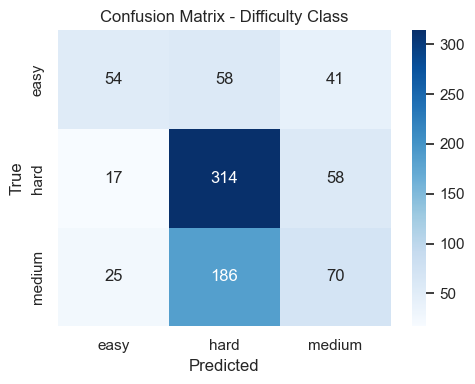

In [14]:
# Visualize confusion matrix
cm = confusion_matrix(y_class_test_enc, y_test_pred_enc)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Difficulty Class")
plt.tight_layout()
plt.show()


### 11. Regression Models and Evaluation

**11.1 Baseline Regression with Cross-Validation**

For the difficulty score (continuous 0–10):

- Use the same feature space (X_train_final).

- Compare:

  - Linear Regression (baseline, may be brittle in high dimension).

  - Gradient Boosting Regressor:

    - Ensemble of decision trees trained sequentially.

    - Each tree corrects residuals of previous trees, minimizing a loss function.

- Evaluate using RMSE (root mean squared error) via K-Fold CV.

In [15]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression baseline
lin_reg = LinearRegression()
lin_rmse_scores = -cross_val_score(
    lin_reg,
    X_train_final,
    y_score_train,
    cv=cv_reg,
    scoring="neg_root_mean_squared_error"
)

print("Linear Regression CV RMSE:", lin_rmse_scores)
print("Mean RMSE:", lin_rmse_scores.mean(), "Std:", lin_rmse_scores.std())

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_rmse_scores = -cross_val_score(
    gb_reg,
    X_train_final,
    y_score_train,
    cv=cv_reg,
    scoring="neg_root_mean_squared_error"
)

print("\nGradient Boosting CV RMSE:", gb_rmse_scores)
print("Mean RMSE:", gb_rmse_scores.mean(), "Std:", gb_rmse_scores.std())


Linear Regression CV RMSE: [  2.44114723  75.85660012  82.59401992 115.38460446   2.14703423]
Mean RMSE: 55.684681191773166 Std: 45.59880088994406

Gradient Boosting CV RMSE: [2.01721044 2.02694623 2.02963878 1.97640871 1.99409114]
Mean RMSE: 2.0088590601763636 Std: 0.02049295061603739


**11.2 Hyperparameter Tuning for Gradient Boosting**

- Gradient Boosting has several key hyperparameters:

- n_estimators – number of trees.

- learning_rate – how much each tree contributes (controls overfitting).

- max_depth – depth of each tree, controls complexity.

- min_samples_leaf – regularization (minimum samples in leaf nodes).

Use RandomizedSearchCV for efficiency, exploring a small hyperparameter space.



In [16]:
param_dist_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 5, 10]
}

rand_search_gb = RandomizedSearchCV(
    estimator=gb_reg,
    param_distributions=param_dist_gb,
    n_iter=5,
    cv=KFold(n_splits=2, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_search_gb.fit(X_train_final, y_score_train)

print("Best RMSE (CV):", -rand_search_gb.best_score_)
print("Best Params:", rand_search_gb.best_params_)


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best RMSE (CV): 2.035229710008731
Best Params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 4, 'learning_rate': 0.03}


**11.3 Final Regression Model and Test Evaluation**

After hyperparameter search, either:

- Use rand_search_gb.best_estimator_, or

- Fix a slightly conservative configuration (e.g., 300 trees, small learning rate).

Then evaluate on the test set with:

- RMSE

- MAE (Mean Absolute Error)

- Plot predicted vs true scores to visually inspect calibration.

In [17]:
# Use either tuned estimator or a chosen config
gb_final = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_final.fit(X_train_final, y_score_train)

y_score_pred = gb_final.predict(X_test_final)

rmse_test = np.sqrt(mean_squared_error(y_score_test, y_score_pred))
mae_test = mean_absolute_error(y_score_test, y_score_pred)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)


Test RMSE: 2.00498587596746
Test MAE: 1.6810055660118064


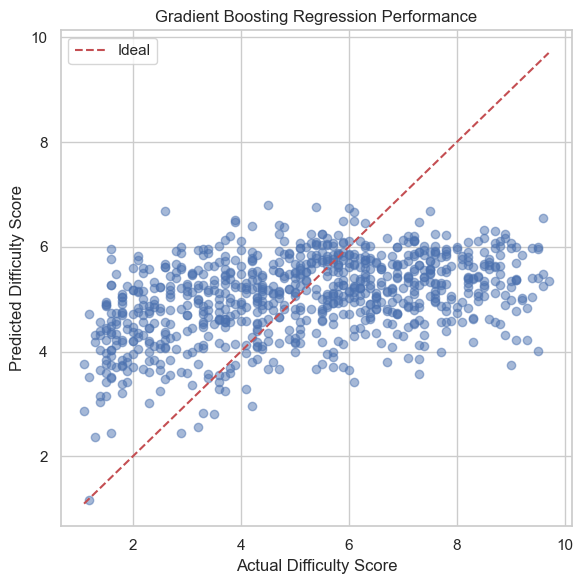

In [18]:
# Scatter plot: true vs predicted difficulty scores
plt.figure(figsize=(6, 6))
plt.scatter(y_score_test, y_score_pred, alpha=0.5)
plt.xlabel("Actual Difficulty Score")
plt.ylabel("Predicted Difficulty Score")
plt.title("Gradient Boosting Regression Performance")
plt.plot([y_score_test.min(), y_score_test.max()],
         [y_score_test.min(), y_score_test.max()],
         "r--", label="Ideal")
plt.legend()
plt.tight_layout()
plt.show()


### 12. Model Persistence for Deployment

To deploy in a Streamlit web app, the entire preprocessing and model pipeline must be reusable:

- Save:

  - tfidf vectorizer

  - best_lr_cls (classification model)

  - gb_final (regression model)

  - LabelEncoder for class decoding

- Store them in a permanent directory (e.g., models/ or your drive path).

Later, the web app will:

1. Load all these artifacts from disk.

2. Apply the same text cleaning, numeric feature extraction, TF–IDF transformation, and feature concatenation.

3. Call both models to get class label and score.

In [19]:
import os
import joblib  # Use joblib since that's what you used in the notebook

os.makedirs("models", exist_ok=True)

joblib.dump(tfidf, "models/tfidf.pkl")
joblib.dump(best_lr_cls, "models/logreg_classifier.pkl")
joblib.dump(gb_final, "models/gb_regressor.pkl")
joblib.dump(le, "models/label_encoder.pkl")

print("✅ All 4 models saved successfully")
print("Files created:")
print(os.listdir("models"))


✅ All 4 models saved successfully
Files created:
['logreg_classifier.pkl', 'label_encoder.pkl', 'tfidf.pkl', 'gb_regressor.pkl', '.ipynb_checkpoints', 'regressor.pkl', 'classifier.pkl']
